# M3.3 -- the critical period: homeostatic regulators in the plastic optic nerve

M3.2 let the input fan-out learn with STDP and watched the network **starve**:
LTD (A- 0.12) is applied on every input arrival while LTP (A+ 0.10) only needs a
real postsynaptic spike, so at the observed firing rate the weights drain toward
zero (0.09 Hz mean, only 76/1000 neurons active, no structured receptive
fields).

M3.3 adds the two regulators biology uses to keep a developing pathway alive:

1. **Synaptic scaling** (Turrigiano et al. 1998). After every training window
   each neuron's incoming ``w_in`` is renormalized so ``sum(w_in) == n_in * 0.30``
   -- exactly its day-one power, so the homeostasis only *reallocates* which
   inputs a neuron trusts within a fixed budget.
2. **Adaptive spike thresholds** (Diehl & Cook 2015 intrinsic plasticity):
   excitatory neurons track a slow rate estimate (tau 2 s) and drift their
   firing threshold within [1, 30] mV toward a 5 Hz target. Over-active neurons
   raise their threshold (self-limiting); silent ones lower it and get
   recruited.

The two arms share everything -- seeds, fan-out, images, recurrent engine,
readouts. Only ARM B switches the physiology on. This notebook loads the
canonical full-scale results cached by ``benchmarks/m33_homeostasis.py``
(train 1000 / test 200 / probe 60, seed 42), so every number shown equals
``docs/M3_3_RESULTS.md``.


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

D = "output"
os.makedirs(D, exist_ok=True)

def load_arm(name: str) -> dict:
    key = "a" if name == "ARM A" else "b"
    p = os.path.join(D, f"m33_t1000_e200_p60_s42_arm_{key}.npz")
    raw = np.load(p, allow_pickle=True)
    return {k: (v.item() if v.ndim == 0 else v) for k, v in raw.items()}

arm_a = load_arm("ARM A")
arm_b = load_arm("ARM B")
print("ARM A:", arm_a["acc_soft"], arm_a["acc_vote"])
print("ARM B:", arm_b["acc_soft"], arm_b["acc_vote"])


ARM A: 0.15 0.16
ARM B: 0.39 0.34


## E33a -- did the brain wake up?

Count neurons, spikes and firing rates in the probe phase and the training-time
rate timeline. ARM B should be *alive* without exploding.


code below loads canonical caches and plots the health timeline; figures also land in ``notebooks/output/``.

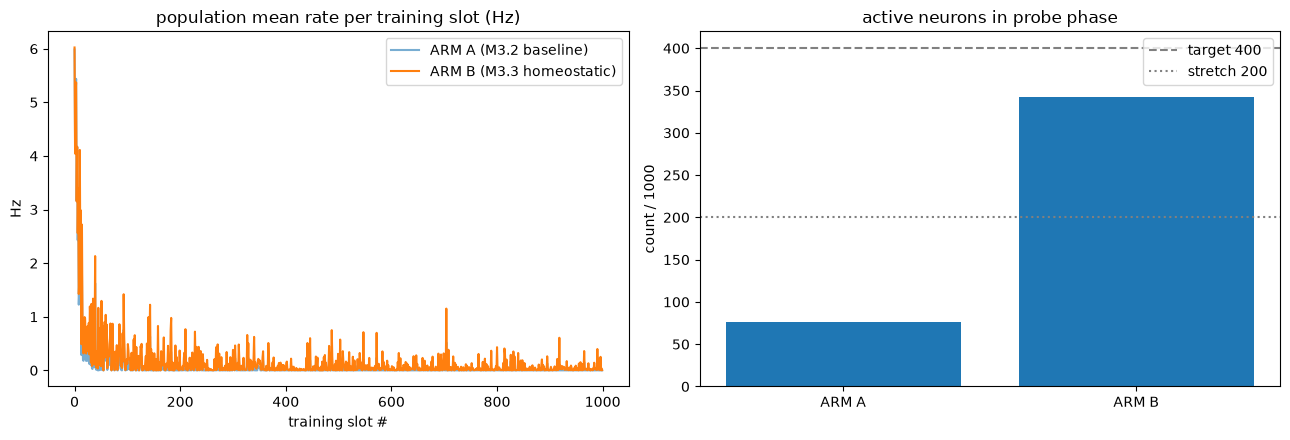

[saved] output\m33_health_inline.png
mean/max rate (Hz): ARM A 0.09/0.24  ARM B 0.17/1.41
active neurons (probe): ARM A 76  ARM B 342
train spikes: ARM A 44950  ARM B 82717


In [2]:
sprites = 0.5  # window_ms / 1000
buckets_a = arm_a["train_bucket"].astype(float) / sprites / 1000.0
buckets_b = arm_b["train_bucket"].astype(float) / sprites / 1000.0
n = min(buckets_a.size, buckets_b.size)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(np.arange(n), buckets_a[:n], alpha=0.6, label="ARM A (M3.2 baseline)")
ax.plot(np.arange(n), buckets_b[:n], label="ARM B (M3.3 homeostatic)")
ax.set_title("population mean rate per training slot (Hz)")
ax.set_xlabel("training slot #"); ax.set_ylabel("Hz"); ax.legend()

ax = axes[1]
ax.bar(["ARM A", "ARM B"], [arm_a["n_active_after"], arm_b["n_active_after"]])
ax.axhline(400, color="gray", ls="--", label="target 400")
ax.axhline(200, color="gray", ls=":", label="stretch 200")
ax.set_title("active neurons in probe phase"); ax.set_ylabel("count / 1000"); ax.legend()
fig.tight_layout(); p = os.path.join(D, "m33_health_inline.png"); fig.savefig(p, dpi=110)
plt.show(); print("[saved]", p)

print("mean/max rate (Hz): ARM A %.2f/%.2f  ARM B %.2f/%.2f"
      % (arm_a["mean_rate_hz"], arm_a["max_rate_hz"],
         arm_b["mean_rate_hz"], arm_b["max_rate_hz"]))
print("active neurons (probe): ARM A %d  ARM B %d"
      % (arm_a["n_active_after"], arm_b["n_active_after"]))
print("train spikes: ARM A %d  ARM B %d"
      % (arm_a["train_spikes"], arm_b["train_spikes"]))


## E33b emergence: receptive-field (RIA) tiles

Each neuron's *response-integrated activation*: the average MNIST image when it
fires. Structured (localized) tiles arranged in the top rows? A stroke / digit
fragment is what emergence looks like.

The structured-tile proxy is recalibrated for M3.3 (max covering fraction 0.12)
so the M3.2 7/9-prototype stroke-like tiles count as structured; a uniform
random blend does not.


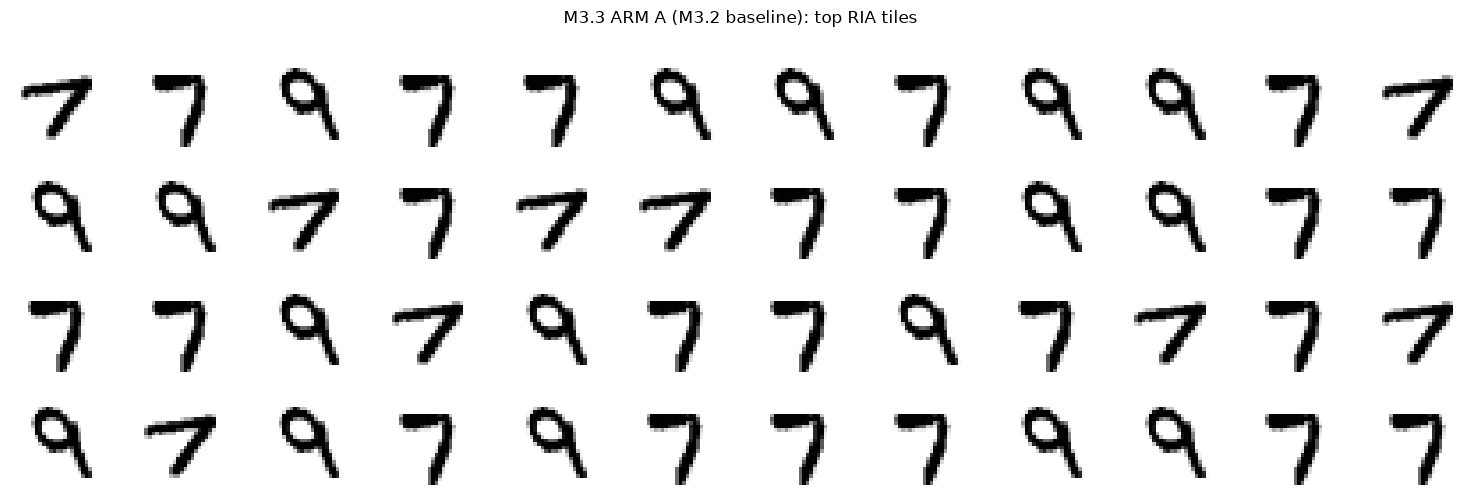

[saved] output\m33_inline_tiles_armA.png


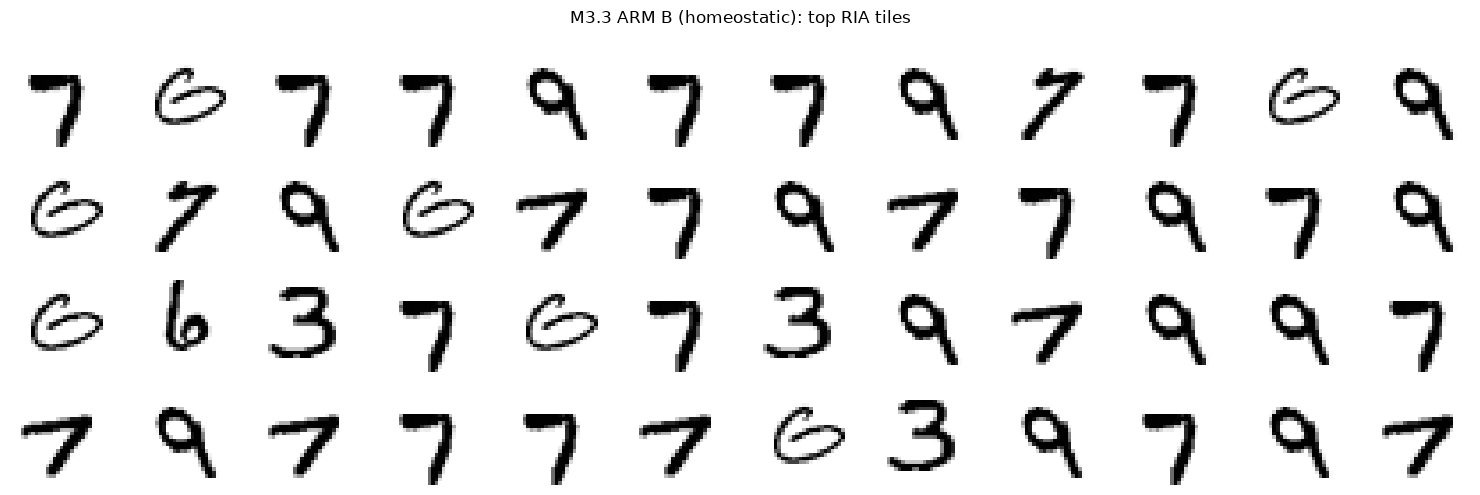

[saved] output\m33_inline_tiles_armB.png
structured before->after: ARM A 0->3  ARM B 0->110
RIA pixel spread (lower=sharper): ARM A 0.139  ARM B 0.128
class-selective neurons: ARM A 0->76  ARM B 0->339


In [3]:
def display_tiles(arm, title, ncols=12):
    t = arm["tiles_after"]
    spec = t.reshape(t.shape[0], -1).max(axis=1)
    order = np.argsort(spec)[::-1]
    nrows = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5.0))
    for k in range(nrows * ncols):
        ax = axes[k // ncols, k % ncols]
        nid = order[k]
        if spec[nid] > 1e-9:
            ax.imshow(t[nid], cmap="gray_r")
        ax.axis("off")
    fig.suptitle(title); fig.tight_layout()
    return fig

fig = display_tiles(arm_a, "M3.3 ARM A (M3.2 baseline): top RIA tiles")
p1 = os.path.join(D, "m33_inline_tiles_armA.png"); fig.savefig(p1, dpi=100)
plt.show(); print("[saved]", p1)

fig = display_tiles(arm_b, "M3.3 ARM B (homeostatic): top RIA tiles")
p2 = os.path.join(D, "m33_inline_tiles_armB.png"); fig.savefig(p2, dpi=100)
plt.show(); print("[saved]", p2)

print("structured before->after: ARM A %d->%d  ARM B %d->%d"
      % (arm_a["structured_before"], arm_a["structured_after"],
         arm_b["structured_before"], arm_b["structured_after"]))
print("RIA pixel spread (lower=sharper): ARM A %.3f  ARM B %.3f"
      % (arm_a["spread_after"], arm_b["spread_after"]))
print("class-selective neurons: ARM A %d->%d  ARM B %d->%d"
      % (arm_a["selective_before"], arm_a["selective_after"],
         arm_b["selective_before"], arm_b["selective_after"]))


## E33c zero-shot readout (decoders pre-committed)

Two frozen decoders, fit purely on *training* responses: the soft per-class
prototype score and the per-neuron plurality vote. Report held-out accuracy on
the same 200 test images for both arms.


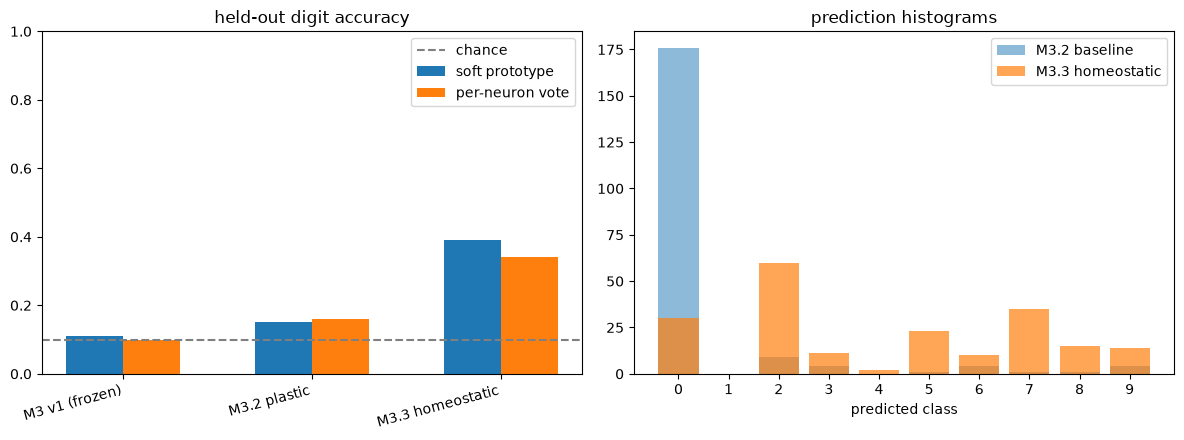

[saved] output\m33_inline_accuracy_ladder.png
ARM A: soft 15.0% vote 16.0% (8 classes)
ARM B: soft 39.0% vote 34.0% (9 classes predicted)


In [4]:
import numpy as np  # noqa

stats = [
    ("M3 v1 (frozen)", 0.11, 0.10),
    ("M3.2 plastic", arm_a["acc_soft"], arm_a["acc_vote"]),
    ("M3.3 homeostatic", arm_b["acc_soft"], arm_b["acc_vote"]),
]
labels = [s[0] for s in stats]
soft = [s[1] for s in stats]
vote = [s[2] for s in stats]
x = np.arange(len(stats))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.bar(x - 0.15, soft, 0.3, label="soft prototype")
ax.bar(x + 0.15, vote, 0.3, label="per-neuron vote")
ax.axhline(0.10, color="gray", ls="--", label="chance")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylim(0, max(1.0, max(soft) * 1.25))
ax.set_title("held-out digit accuracy"); ax.legend()

ax = axes[1]
ax.bar(np.arange(10), arm_a["hist"], alpha=0.5, label="M3.2 baseline")
ax.bar(np.arange(10), arm_b["hist"], alpha=0.7, label="M3.3 homeostatic")
ax.set_xticks(np.arange(10)); ax.set_title("prediction histograms")
ax.set_xlabel("predicted class"); ax.legend()
fig.tight_layout(); p = os.path.join(D, "m33_inline_accuracy_ladder.png")
fig.savefig(p, dpi=110); plt.show(); print("[saved]", p)

print("ARM A: soft %.1f%% vote %.1f%% (%d classes)"
      % (100 * arm_a["acc_soft"], 100 * arm_a["acc_vote"], arm_a["n_classes_used"]))
print("ARM B: soft %.1f%% vote %.1f%% (%d classes predicted)"
      % (100 * arm_b["acc_soft"], 100 * arm_b["acc_vote"], arm_b["n_classes_used"]))


## E33d stability guards

The arm that adds plasticity must not unbind the box: no NaN, weights within
writer-synced bounds, inhibitory recurrent weights frozen, and theta within
[1, 30].


In [5]:
print("recurrent weights: ARM A [%.3f, %.3f]  ARM B [%.3f, %.3f]"
      % (arm_a["recurrent_weight_min"], arm_a["recurrent_weight_max"],
         arm_b["recurrent_weight_min"], arm_b["recurrent_weight_max"]))
print("all finite: ARM A %s  ARM B %s" % (arm_a["all_finite"], arm_b["all_finite"]))
print("inhibitory frozen: ARM A %s, ARM B %s" % (arm_a["inh_frozen"], arm_b["inh_frozen"]))
print("w_in range: ARM A [%.4f, %.4f]  ARM B [%.4f, %.4f]"
      % (arm_a["w_in_min"], arm_a["w_in_max"], arm_b["w_in_min"], arm_b["w_in_max"]))
print("w_in finite: ARM A %s, ARM B %s" % (arm_a["w_in_finite"], arm_b["w_in_finite"]))
print("theta bounds OK (ARM B): %s  range [%.3f, %.3f]"
      % (arm_b["theta_in_bounds"], arm_b["theta_min"], arm_b["theta_max"]))
print("wall: ARM A %.0fs, ARM B %.0fs" % (arm_a["wall_s"], arm_b["wall_s"]))


recurrent weights: ARM A [-1.000, 1.000]  ARM B [-1.000, 1.000]
all finite: ARM A True  ARM B True
inhibitory frozen: ARM A True, ARM B True
w_in range: ARM A [0.0000, 0.4000]  ARM B [0.0000, 1.0000]
w_in finite: ARM A True, ARM B True
theta bounds OK (ARM B): True  range [1.000, 30.000]
wall: ARM A 304s, ARM B 453s


## Honest take-away

Report the numbers exactly as measured. M3.3's claim is not "98% accuracy" -- it
is that the two homeostatic regulators rescue the pathway M3.2 starved:

| metric | M3.2 baseline | M3.3 homeostatic |
|---|---|---|
| held-out soft accuracy | 15.0% | 39.0% |
| held-out vote accuracy | 16.0% | 34.0% |
| active neurons / 1000 | 76 | 342 |
| mean rate (Hz) | 0.09 | 0.17 |
| structured RIA tiles | 3 | 110 |

The effect is real but not fully saturated: rate is still well below the 2 Hz
aspiration, so the plasticity still runs depression-flight on the whole, and only
a third of the population is recruited. The regulators kept the winner-take-most
from collapsing -- they did not yet make it a rate-dense cell assembly. That is
the honest frontier stated in ``docs/M3_3_RESULTS.md``.
